In [25]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import seaborn as sns
sns.set_theme(style="darkgrid")
palette = "viridis"
sns.set_palette(palette)


In [26]:
# Configuration
# Use ["random"], ["evolved"], or ["random", "evolved"].
CONDITIONS_TO_PLOT = ["random", "evolved"]

SEEDS = [1, 2, 3, 4]
LOSS_KIND = "mean"  # "best" uses phase3_best_losses.npy; "mean" uses phase3_mean_losses.npy
SMOOTHING_WINDOW = 1  # set to e.g. 5 or 10 to smooth the displayed curve

DATA_ROOT = Path("./data")
SAVE_DIR = Path("./figures")
SAVE_DIR.mkdir(exist_ok=True)


In [27]:
def moving_average(values, window):
    values = np.asarray(values, dtype=float)
    if window <= 1:
        return values
    if window > values.shape[0]:
        raise ValueError(f"Smoothing window {window} is longer than the curve length {values.shape[0]}.")
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def phase3_loss_file(condition, seed, loss_kind="best"):
    if condition not in {"random", "evolved"}:
        raise ValueError("condition must be 'random' or 'evolved'")
    if loss_kind not in {"best", "mean"}:
        raise ValueError("loss_kind must be 'best' or 'mean'")

    folder = DATA_ROOT / condition / f"phase3_{condition}_seed_{seed}"
    return folder / f"phase3_{loss_kind}_losses.npy"


def load_phase3_losses(condition, seeds=SEEDS, loss_kind=LOSS_KIND, smoothing_window=SMOOTHING_WINDOW):
    curves = []
    missing = []

    for seed in seeds:
        path = phase3_loss_file(condition, seed, loss_kind)
        if not path.exists():
            missing.append(path)
            continue
        curves.append(moving_average(np.load(path), smoothing_window))

    if missing:
        missing_text = "\n".join(str(path) for path in missing)
        raise FileNotFoundError(f"Missing Phase 3 loss files:\n{missing_text}")

    lengths = {curve.shape[0] for curve in curves}
    if len(lengths) != 1:
        raise ValueError(f"Curves have different lengths: {sorted(lengths)}")

    return np.stack(curves, axis=0)


In [28]:
def plot_phase3_condition(condition, seeds=SEEDS, loss_kind=LOSS_KIND, smoothing_window=SMOOTHING_WINDOW):
    losses = load_phase3_losses(condition, seeds, loss_kind, smoothing_window)
    mean_loss = losses.mean(axis=0)
    std_loss = losses.std(axis=0)
    generations = np.arange(mean_loss.shape[0])
    if smoothing_window > 1:
        generations = generations + smoothing_window - 1

    fig, ax = plt.subplots(figsize=(8, 5))
    #color = "#3b82f6" if condition == "random" else "#ef4444"
    color = sns.color_palette(palette)[0] if condition == "random" else sns.color_palette(palette)[1]

    label = f"{condition.capitalize()} agents"

    linestyle = '--' if condition == 'random' else '-'
    ax.plot(generations, mean_loss, label=label, color=color, linewidth=2, linestyle=linestyle)
    ax.fill_between(generations, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.2)


    ax.set_xlabel("Generation", fontsize=15)
    ax.set_ylabel(f"Mean loss", fontsize=15)

    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.legend(frameon=False, fontsize=18)

    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    output_path = SAVE_DIR / f"phase3_{condition}_{loss_kind}_loss_mean_std.svg"
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved {output_path}")
    return fig, ax


Saved figures/phase3_random_mean_loss_mean_std.svg
Saved figures/phase3_evolved_mean_loss_mean_std.svg


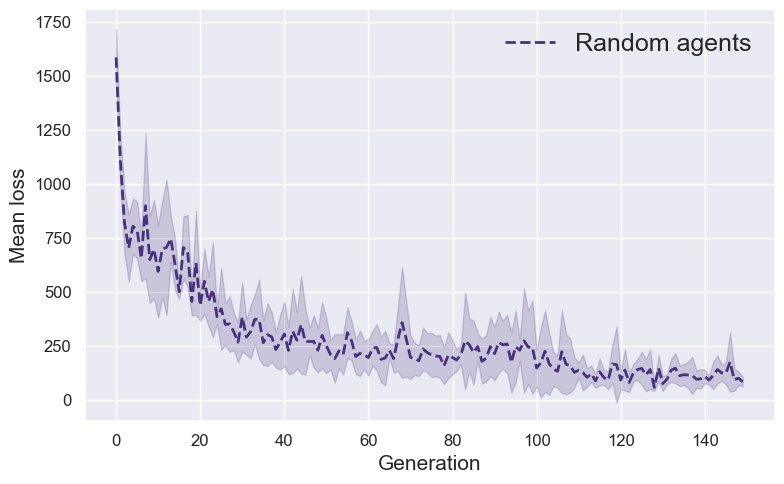

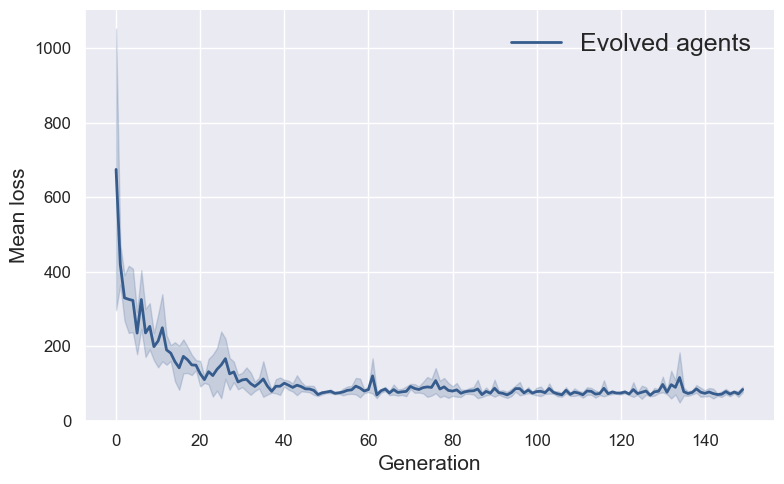

In [29]:
for condition in CONDITIONS_TO_PLOT:
    plot_phase3_condition(condition)


Saved figures/phase3_random_vs_evolved_mean_loss_mean_std.svg


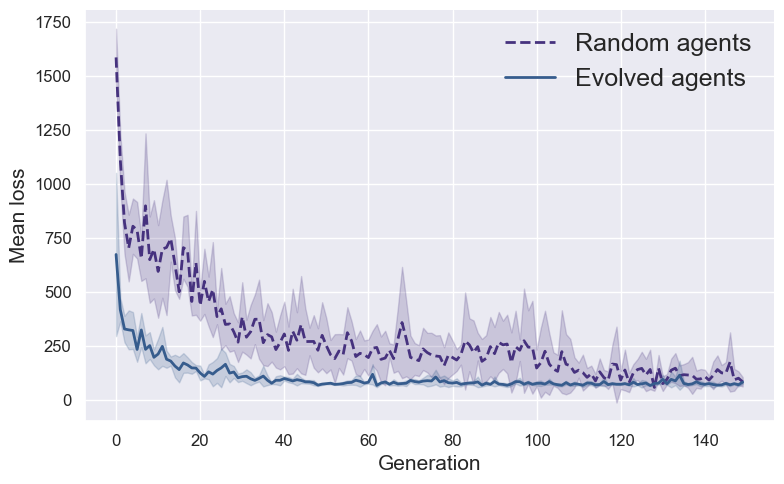

In [30]:
# Optional combined comparison plot.
# Set CONDITIONS_TO_PLOT = ["random", "evolved"] above to use this cell.
def plot_phase3_comparison(conditions=CONDITIONS_TO_PLOT, seeds=SEEDS, loss_kind=LOSS_KIND, smoothing_window=SMOOTHING_WINDOW):
    fig, ax = plt.subplots(figsize=(8, 5))
    #colors = {"random": "#3b82f6", "evolved": "#ef4444"}
    colors = {"random": sns.color_palette(palette)[0], "evolved": sns.color_palette(palette)[1]}

    for condition in conditions:
        losses = load_phase3_losses(condition, seeds, loss_kind, smoothing_window)
        mean_loss = losses.mean(axis=0)
        std_loss = losses.std(axis=0)
        generations = np.arange(mean_loss.shape[0])
        if smoothing_window > 1:
            generations = generations + smoothing_window - 1

        color = colors.get(condition, None)
        linestyle = '--' if condition == 'random' else '-'
        ax.plot(generations, mean_loss, label=f"{condition.capitalize()} agents", color=color, linewidth=2, linestyle=linestyle)
        ax.fill_between(generations, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.2)

    ax.set_xlabel("Generation", fontsize=15)
    ax.set_ylabel(f"Mean loss", fontsize=15)

    ax.tick_params(axis='both', which='major', labelsize=12)

    ax.legend(frameon=False, fontsize=18)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    condition_tag = "_vs_".join(conditions)
    output_path = SAVE_DIR / f"phase3_{condition_tag}_{loss_kind}_loss_mean_std.svg"
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved {output_path}")
    return fig, ax

if len(CONDITIONS_TO_PLOT) > 1:
    plot_phase3_comparison()
